<a href="https://colab.research.google.com/github/hehoha3/TensorFlow_tutorial/blob/dev/1_neural_network_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Có nhiều định nghĩa về **bài toán hồi quy** nhưng đơn giản hóa nó ta có thể hiểu nó là: **dự đoán một con số**.

Ví dụ như các bài toàn:
- Dự đoán giá bán nhà khi có thông tin về ngôi nhà (*số phòng, diện tích, số phòng tắm, ...*).
- Dự đoán tọa độ của hộp giới hạn của một vật trong hình ảnh.
- Dự đoán chi phí bảo hiểm y tế cho một cá nhân dựa trên thông tin nhân khẩu học của họ (*tuổi, giới tính, chủng tộc, ...*).

# Kiến trúc của mạng neauron hồi quy

| Siêu tham số | Giá trị của tham số |
|-------|-------|
| Input layer shape | Có cùng `shape` với số lượng features (*ví dụ: 3 cho # phòng ngủ, # phòng tắm, # chỗ đậu xe trong dự đoán giá nhà*) |
| Hidden layeer | Tùy vấn đề cụ thể, tối thiểu = 1, tối đa = không giới hạn |
| Neurons per hidden layer | Tùy vấn đề cụ thể, thường là từ 10 đến 100  |
| Output layer shape | Có cùng `shape` với dự đoán mong muốn (*ví dụ: 1 cho giá nhà*) |
| Hidden activation | Thông thường là `ReLU` |
| Output activation | Không có hoặc thường là `ReLU` hoặc `logistic/tanh` |
| Loss function | `MSE` (*mean square error*) hoặc `MAE` (*mean absolute error*) hoặc `Huber` (*sự kết hợp của MAE và MSE*) nếu có outliers |
| Optimizer | `SGD` (*stochastic gradient descent*), `Adam` |

In [ ]:
import tensorflow as tf

print(f"Tensorflow version: {tf.__version__}")

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Tensorflow version: 2.19.0
Notebook last run (end-to-end): 2025-08-28 11:21:34.063185


# Tạo dữ liệu để xem và fit
Vì ta đang giải quyết bài toán hồi quy nên hãy tạo một số dữ liệu tuyến tính để mô hình hóa.

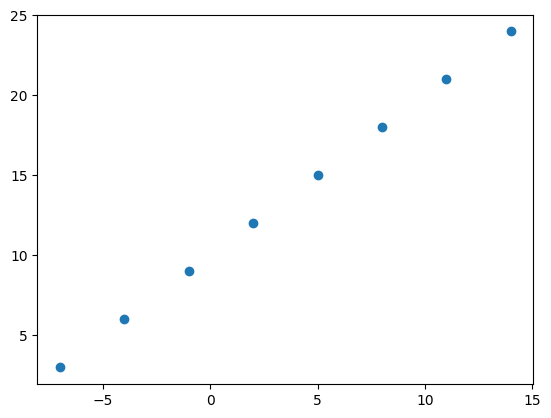

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

> Hãy thử suy nghĩ về 1 mô hình mà nếu như ta có dữ liệu `X = 17` thì nó sẽ biết rằng `y` có giá trị là bao nhiều.

# Input shape và output shape của bài toán hồi quy
Một trong những khái niệm quan trọng nhất khi làm việc với mạng nơ-ron là input shape và ouput shape.
- Input shape và output shape cũng giống như tên gọi của chúng, chúng là shape của dữ liệu mà ta đưa vào mô hình và shape của dữ liệu mà mô hình tạo ra.

> Những điều này sẽ khác nhau tùy thuộc vào bài toán mà ta đang gặp phải

Mạng nơ-ron nhân tạo chấp nhận dạng số làm input và xuất ra số. Những số này thường được biểu diễn dưới dạng tensor hoặc mảng.

Trước đây, ta tạo dữ liệu bằng mảng NumPy, nhưng ta có thể làm tương tự với tensor.

In [ ]:
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])

house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

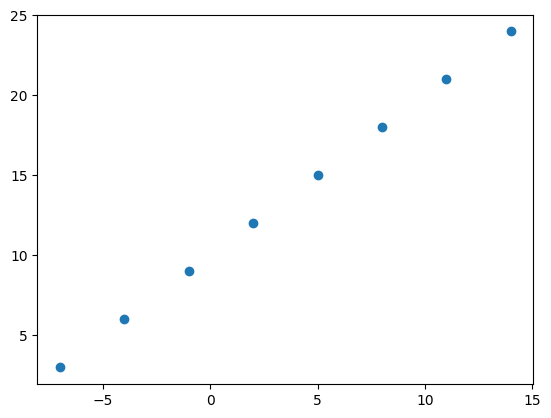

In [ ]:
# Create features
X = tf.constant([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = tf.constant([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

Mục tiêu của bài toán của ta sẽ là sử dụng `X` để dự đoán `y`, vì thế input của mô hình sẽ là `X` và output của nó sẽ là `y`.

Ta sẽ muốn xem coi input shape của mô hình là như thế nào.

In [ ]:
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

Nhưng X và y là toàn bộ các dữ liệu ta đưa vào mô hình và toàn bộ các dữ liệu mà mô hình đưa ra.

Ta sẽ lần lượt đưa từng X vào mô hình và mô hình sẽ đưa ra đầu ra cho ta là tứng biến y

In [ ]:
X[0], y[0]

(<tf.Tensor: shape=(), dtype=float32, numpy=-7.0>,
 <tf.Tensor: shape=(), dtype=float32, numpy=3.0>)

Ta thấy chúng luôn luôn có cùng `shape` với nhau.

Và đúng như vậy, đây một trong những công việc chiếm nhiều thời gian nhất khi thực hiện xây dựng 1 mô hình, đó là đảm bảo `input shape` phải có shape tương ứng với `output shape`

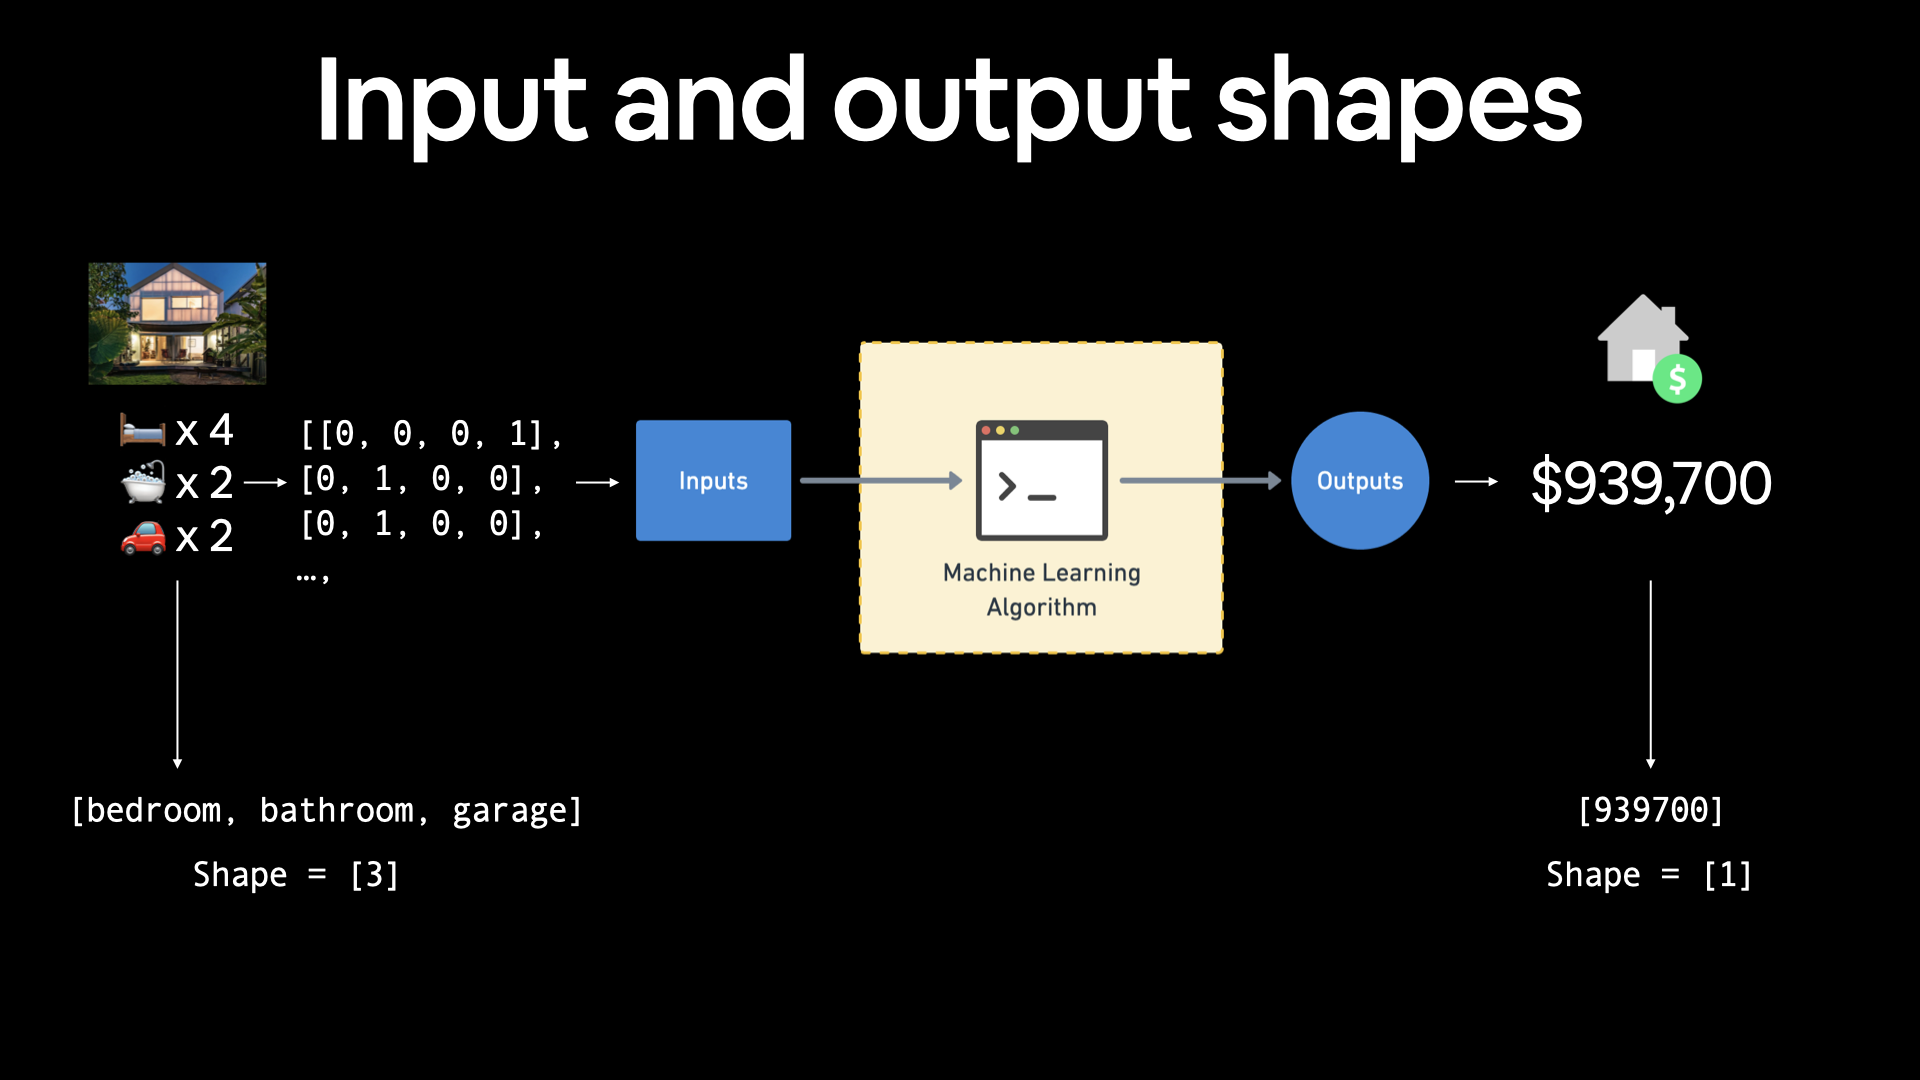

# Các bước trong mô hình hóa với TensorFlow
Bây giờ ta hãy cùng xem cách xây dựng mạng nơ-ron để mô hình hóa dữ liệu đó.

Trong TensorFlow, thường có 3 bước cơ bản để tạo và đào tạo một mô hình:
1. **Tạo mô hình** - tự ghép các layer của mạng nơ-ron (*sử dụng Functional API hoặc Sequential API*) hoặc import 1 mô hình đã được xây dựng trước đó (*được gọi là transfer learning - học chuyển giao*).
2. **Compiling mô hình** - xác định cách đo lường hiệu suất của mô hình qua loss/metrics cũng như xác định cách cải thiện mô hình với optimizer
3. **Fit mô hình** - để mô hình cố gắng tìm ra các pattens (*mẫu*) trong dữ liệu

Hãy cùng xem xét cách thức hoạt động của chúng bằng cách sử dụng [Keras Sequential API](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential) để xây dựng mô hình cho dữ liệu hồi quy. Sau đó, ta sẽ lần lượt tìm hiểu từng bước.

> **Lưu ý**: vì layer `Dense` trong Keras chờ input có shape `(batch_size, features)` — còn X của ta hiện tại là tensor 1 chiều có shape `(8,)`.
>
> `tf.expand_dims(X, axis=-1)` thêm một chiều cuối cùng để biến X có shape `(8, 1)` (*8 mẫu, mỗi mẫu 1 feature*), để phù hợp với layer `Dense(1)`.

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create a model
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 8.6518 - mae: 8.6518
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 8.5193 - mae: 8.5193
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 8.3868 - mae: 8.3868
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 8.2543 - mae: 8.2543
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 8.1218 - mae: 8.1218


Ok vậy là ta đã thực hiện xây dựng 1 mô hình, bây giờ hãy thử để nó dự đoán y dựa trên X ta truyền vào.

Trước tiên ta hãy xem coi X và y của ta đang là như thế nào

In [ ]:
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

Bây giờ ta hãy đưa vào nó 1 số để xem nó dự đoán thế nào

In [ ]:
model.predict(tf.constant([-7.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


array([[-10.871303]], dtype=float32)


> 🤔 Ta sẽ cần tìm hiểu thêm về `keras` để biết được nó là gì ?

# Cải thiện mô hình
Vậy ta có thể cải thiện được mô hình như thế nào để nó có thể dự đoán chính xác hơn ?

**Để cải thiện mô hình, ta thay đổi hầu hết mọi phần trong 3 bước đã thực hiện trước đó.**
1. **Tạo mô hình** - ở đây ta có thể muốn thêm nhiều layer hơn, tăng số lượng hidden units (*còn gọi là nơ-ron*) trong mỗi layer, thay đổi activation func của mỗi layer.
2. **Compiling mô hình** - ta có thể muốn chọn hàm optimizer khác hoặc có thể thay đổi learning rate của hàm optimizer.
3. **Fit mô hình** - có lẽ ta có thể fit với mô hình cho nhiều `epochs` hơn (*để quá trình đào tạo kéo dài hơn*) hoặc trên nhiều dữ liệu hơn (*cung cấp cho mô hình nhiều ví dụ hơn để học tập hơn*)

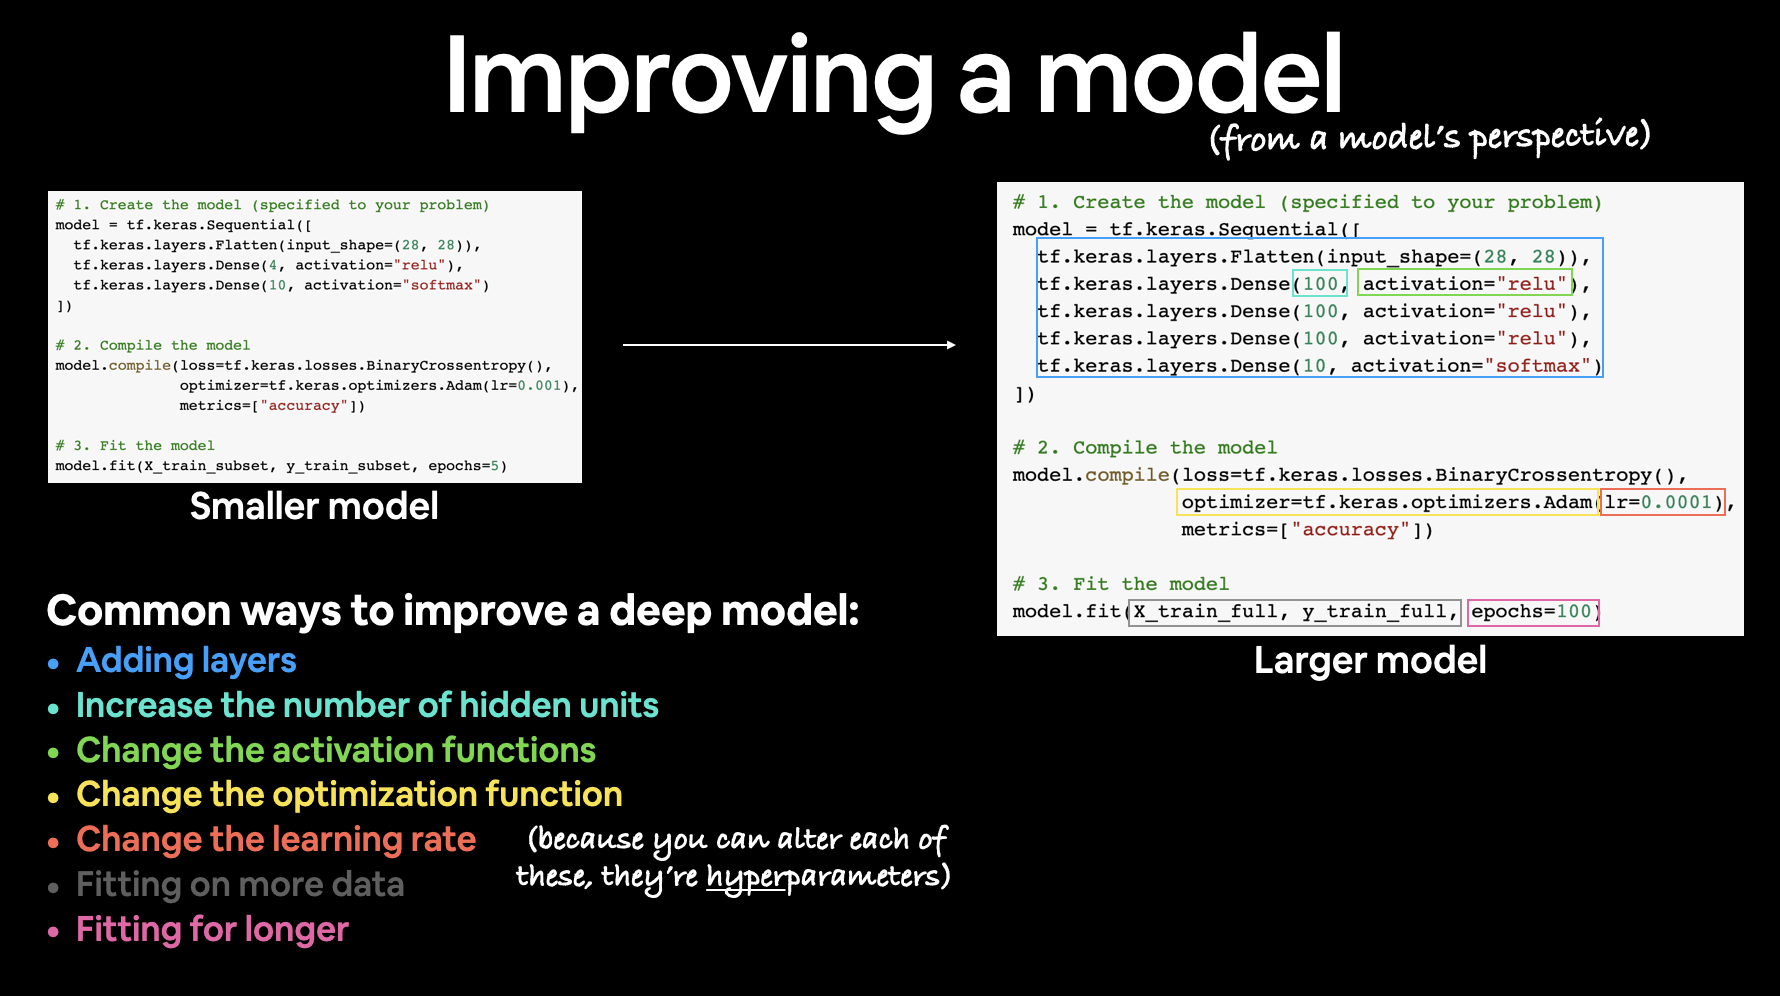

Tại đây để đơn giản nhất có thể, ta sẽ tăng số lượng Epochs để tăng thời gian học tập của mô hình

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Create a model
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step - loss: 20.0530 - mae: 20.0530
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 19.7717 - mae: 19.7717
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 19.4905 - mae: 19.4905
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - loss: 19.2092 - mae: 19.2092
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 18.9280 - mae: 18.9280
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - loss: 18.6467 - mae: 18.6467
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 18.3655 - mae: 18.3655
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 18.0842 - mae: 18.0842
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 17.8030 - mae: 17.8030
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 17.5217 - mae: 17.5217
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 17.2405 - mae: 17.2405
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 16.9592 - mae: 16.9592
Epoch 13/100
1

Ta có thể quan sát thấy `loss` của mô hình đã đi giảm nhiều so với mô hình ban đầu.

Ta hãy thử sử dụng nó để dự đoán xem thế nào.

In [ ]:
model.predict(tf.constant([-7.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[-10.802683]], dtype=float32)

# Đánh giá một mô hình
Quy trình làm việc điển hình khi xây dựng mạng lưới nơ-ron là:

`Xây dựng mô hình -> đánh giá -> xây dựng mô hình mới -> đánh giá -> xây dựng mô hình mới -> đánh giá...`

Việc xây dựng mô hình mới không phải hoàn toàn là việc xây dựng một mô hình từ đầu mà là điều chỉnh một mô hình hiện có.

Và để đánh giá một mô hình đầu tiên ta cần cho nó `hiển thị`

## Hiển thị
Có nhiều thứ mà ta có thể cho nó hiển thị:
- **Data** (*dữ liệu*) - ta đang làm việc với dữ liệu nào? Dữ liệu đó trông như thế nào?
- **Mô hình** - kiến trúc trông như thế nào? Có những shape khác nhau thế nào?
- **Quá trình đào tạo mô hình** - mô hình hoạt động như thế nào trong quá trình học?
- **Dự đoán của mô hình** - dự đoán của một mô hình phù hợp như thế nào với sự thật cơ bản (*label gốc*)?

Trước tiên, ta sẽ tạo một dataset lớn hơn một chút và một mô hình mới để sử dụng.

In [ ]:
X = np.arange(-100, 100, 4)
X

array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])

In [ ]:
y = np.arange(-90, 110, 4)
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

Khi quan sát vào dataset trên với X và y ta có thể thấy được 1 một phương trình như sau: `𝑦 = 𝑋 + 10`

Ta cũng hãy thử thực hiện phương trình trên để xem nó có xuất đúng y cho ta không

In [ ]:
y = X + 10
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

# Chia dữ liệu
Ta sẽ cần chia dữ liệu của mình ra thành training set, test set hoặc đối với các mô hình lớn và có nhiều dữ liệu ta có thể chia thành training set, validation set và test set.

Nhưng trước khi chia dữ liệu, ta cần biết được dữ liệu hiện tại của ta có là bao nhiêu

In [ ]:
len(X)

50

In [ ]:
X_train = X[:40]
y_train = y[:40]

X_test = X[40:]
y_test = y[40:]

len(X_train), len(X_test)

(40, 10)

# Hiển thị dữ liệu
Hiện tại ta đã có được training set và test set để đưa vào mô hình, bây giờ là lúc ta muốn xem coi chúng như thế nào

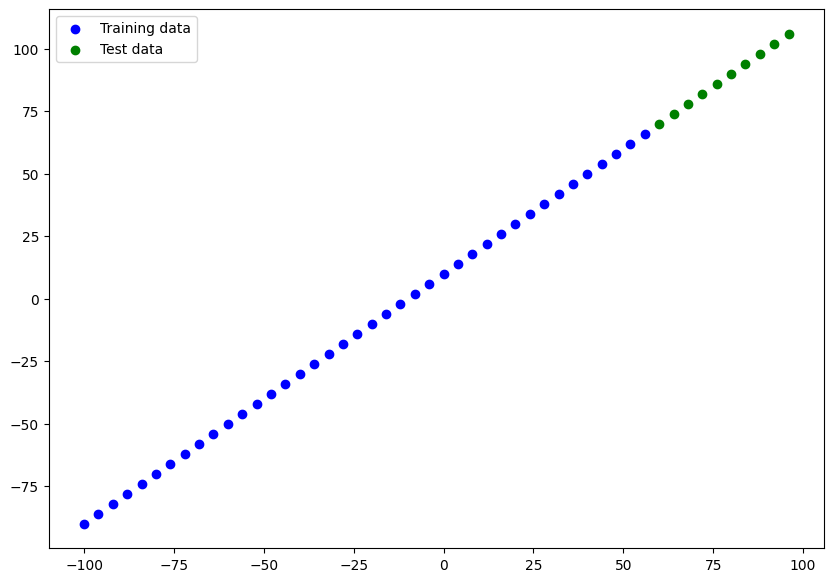

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", label="Training data")
plt.scatter(X_test, y_test, c="g", label="Test data")
plt.legend() # show legend

Rất tốt, bất cứ khi nào ta làm việc với data, mô hình hay nhiều thứ khác thì việc hiển thị chúng là 1 ý tưởng hay !!

Với biểu đồ dữ liệu này, ta sẽ cố gắng xây dựng một mô hình có thể học được pattens (*mãu*) trong các chấm màu xanh dương (*biểu thị cho training set*) để vẽ các chấm màu xanh lá cây (*biểu thị cho test set*).

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

model.compile(loss=tf.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=["mae"])

# Hiển thị mô hình
Sau khi xây dựng xong một mô hình, ta có thể muốn xem lại nó.

Ta có thể xem các layer và shape của mô hình bằng cách gọi hàm `summary()` trên đó.

> Lưu ý: Việc trực quan hóa mô hình đặc biệt hữu ích khi ta gặp phải sự không khớp về shape của input và output

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Bởi vì ta chưa fit mô hình (*unbuild*) nên nó sẽ không hiển thị nhiều thông tin cho ta.

Và vì ta chưa cho nó biết `input shape` của nó trông như thế nào nên nó cũng sẽ không biết nên hiển thị `output shape` như thế nào hết.

> Nhưng ta có thể cho mô hình biết `input shape` của dữ liệu bằng cách sử dụng tham số `input_shape` ở layer đầu tiên (*thường thì nếu input_shape không được xác định, Keras sẽ cố gắng tự động xác định*).

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
  tf.keras.layers.Dense(1, input_shape=[1])
])

model.compile(loss=tf.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Khi gọi hàm `summary()` trên mô hình của ta sẽ hiển thị các layer chứa trong đó, input shape và số lượng tham số.

- **Total param** - tổng số tham số trong mô hình.
- **Trainable parameters** - đây là các tham số (*pattens*) mà mô hình có thể cập nhật trong quá trình đào tạo.
- **Non-trainable parameters** - các tham số này không được cập nhật trong quá trình đào tạo (*điều này thường xảy ra khi ta đưa các pattens đã học được từ các mô hình khác vào trong quá trình transfer learning - học chuyển giao*).

Ta có thể thử thay đổi các tham số trong `tf.keras.layers.Dense` để xem các param của ta thay đôi như thế nào

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
  tf.keras.layers.Dense(3, input_shape=[1]),
])

model.compile(loss=tf.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=["mae"])

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 3)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
  tf.keras.layers.Dense(10, input_shape=[1]),
])

model.compile(loss=tf.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=["mae"])

In [ ]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

OK OK, bây giờ là lúc cho mô hình của ta gặp gỡ với input data của ta bằng việc **Fit mô hình**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
  tf.keras.layers.Dense(1, input_shape=[1])
])

model.compile(loss=tf.losses.mae, optimizer=tf.keras.optimizers.SGD(), metrics=["mae"])

model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much gets output

In [ ]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Ta thấy sau khi thực hiện **Fit mô hình** ta nhận thêm được 1 param nữa đó là `Optimizer params`.

Đây là các biến trạng thái mà optimizer (*SGD, Adam, …*) tạo ra để hỗ trợ quá trình tối ưu hóa mô hình:

- Với SGD đơn giản: thường lưu momentum hoặc trạng thái gradient trước đó.
- Với Adam: lưu moment 1 (*m*) và moment 2 (*v*).

Bên cạnh hàm `summary()`, ta cũng có thể xem sơ đồ 2D của mô hình bằng cách sử dụng hàm `plot_model()`.

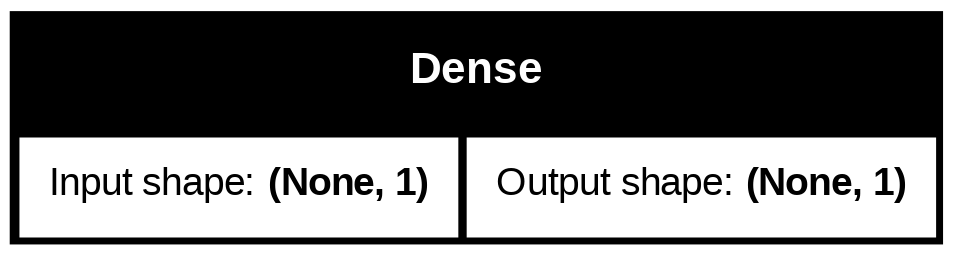

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

# Hiển thị các dự đoán
Bây giờ ta đã 1 mô hình đã được huấn luyện, hãy thử hiển thị các dự đoán của nó.

Để hiển thị và hình dung ra các dự đoán của mô hình, việc xem các label thực ở bước đầu tiên là việc rất nên làm.

Nhưng trước tiên ta sẽ cần để mô hình của ta dự đoán với dữ liệu trên Test set

In [ ]:
y_preds = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [ ]:
y_test

array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [ ]:
y_preds

array([[ 69.7897  ],
       [ 74.34785 ],
       [ 78.90599 ],
       [ 83.46414 ],
       [ 88.022285],
       [ 92.58044 ],
       [ 97.13858 ],
       [101.696724],
       [106.254875],
       [110.81302 ]], dtype=float32)

Ta đã được thấy các label thực tế và các label được mô hình dự đoán, nhưng nó vẫn chưa thể nói lên được điều gì quá nhiều.

Ta sẽ cần hiển thị chúng để so sánh chúng với nhau như thế nào

In [ ]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_preds):
  plt.figure(figsize=(10, 7))
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  plt.legend()

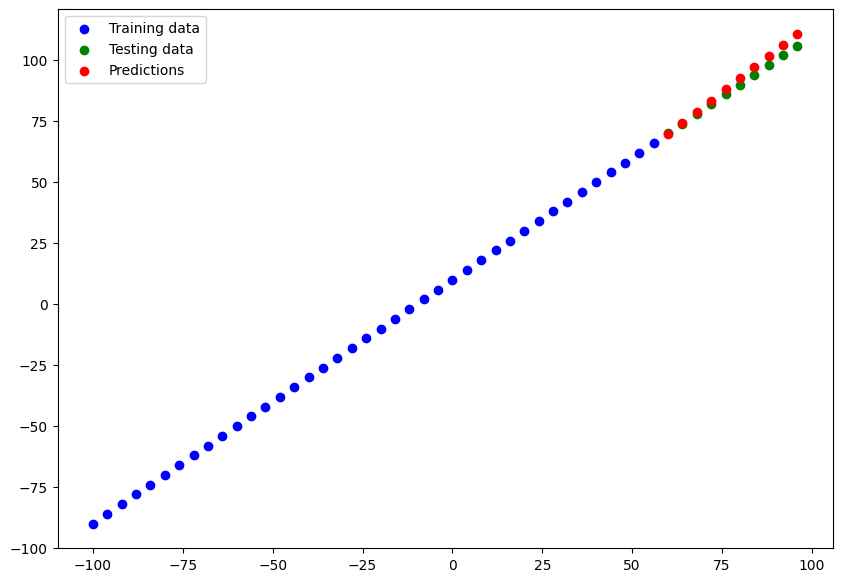

In [ ]:
plot_predictions()

Từ biểu đồ trên, ta có thể thấy những dự đoán của mình không hoàn toàn ngớ ngẩn nhưng chắc chắn cũng không có gì là quá tốt.

# Đánh giá dự đoán của mô hình
Đi kèm với sự hình ảnh hóa, thì số liệu cũng là thứ rất tốt đi kèm với nó để đánh giá 1 mô hình.

2 trong số các số liệu chính được sử dụng cho các bài toán hồi quy là:
- **Mean absolute error (MAE)** - sự khác biệt trung bình giữa mỗi dự đoán
- **Mean squared error (MSE)** - sự khác biệt trung bình bình phương giữa các dự đoán (*sử dụng nếu lỗi lớn hơn có hại hơn lỗi nhỏ hơn*).

> ### Mỗi giá trị này càng thấp thì càng tốt

Ta cũng có thể sử dụng hàm `evaluate()` để trả về giá trị `loss` của mô hình cũng như bất kỳ thiết lập số liệu nào trong bước biên dịch.

In [ ]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 2.3434 - mae: 2.3434


[2.3434195518493652, 2.3434195518493652]

Trong trường hợp của ta, vì ta sử dụng MAE cho `loss function` cũng như MAE cho `metrics`, vậy nên `model.evaulate()` trả về cả giá trị `loss` và `mae` giống nhau.

Ngoài ra `Tensorflow` cũng xây dựng cá hàm riêng biệt cho MSE và MAE

In [ ]:
mae = tf.keras.losses.mae(y_test, y_preds)
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([0.21029663, 0.34784698, 0.9059906 , 1.4641418 , 2.0222855 ,
       2.5804367 , 3.1385803 , 3.696724  , 4.254875  , 4.813019  ],
      dtype=float32)>

Đúng ra, `mea` sẽ chỉ đưa ra cho ta đúng 1 giá trị duy nhất mà thôi. Nhưng tại sao đây lại có 10 giá trị.

- Điều này là do tensor `y_test` và `y_preds` đang có shape khác nhau.

In [ ]:
y_test

array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [ ]:
y_preds

array([[ 69.7897  ],
       [ 74.34785 ],
       [ 78.90599 ],
       [ 83.46414 ],
       [ 88.022285],
       [ 92.58044 ],
       [ 97.13858 ],
       [101.696724],
       [106.254875],
       [110.81302 ]], dtype=float32)

In [ ]:
y_test.shape, y_preds.shape

((10,), (10, 1))

Hãy nhớ rằng, ta đã nhắc tới vấn đề kiểm soát `shape` của cả input và output. Và sự chênh lệch `shape` này cũng là 1 trong số các vấn đề trên.

Ta có thể sửa lỗi này bằng cách sử dụng `squeeze()`, nó sẽ xóa chiều thứ 1 khỏi tensor `y_preds`, khiến nó có cùng `shape` với `y_test`.


In [ ]:
print(f"Before squeeze: {y_preds.shape}")
print(f"After squeeze: {y_preds.squeeze().shape}")

Before squeeze: (10, 1)
After squeeze: (10,)


Ok bây giờ ta hãy thử tính lại `MAE` xem nó đã được thay đổi như thế nào

In [ ]:
mae = tf.keras.losses.mae(y_test, tf.squeeze(y_preds))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=2.3434195518493652>

Ta cũng muốn xem coi chỉ số `MSE` của mô hình trông như thế nào

In [ ]:
mse = tf.keras.losses.mse(y_test, tf.squeeze(y_preds))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=7.866361141204834>

ta cũng có thể tính toán `MAE` bằng cách sử dụng các hàm TensorFlow thuần túy.

In [ ]:
tf.reduce_mean(tf.abs(y_test - tf.squeeze(y_preds)))

<tf.Tensor: shape=(), dtype=float32, numpy=2.3434195518493652>

Ta có thể sẽ cần sử dụng chúng nhiều lần sau này, nên việc hãy tạo cho chúng 1 hàm để có thể sử dụng nhiều lần là việc rất nên làm.

In [ ]:
def mae(y_test, y_pred):
  return tf.keras.losses.mae(y_test, y_pred)

def mse(y_test, y_pred):
  return tf.keras.losses.mse(y_test, y_pred)

# Tiến hành cải thiện mô hình và đánh giá
Có rất nhiều cách để ta có thể cải thiện được mô hình của mình, nhưng trong đó có 3 cách chính:
1. **Lấy thêm dữ liệu** - có thêm dữ liệu để mô hình có thể đào tạo nhiều (*nhiều cơ hội hơn để học từ các mẫu*).
2. **Làm cho mô hình của bạn lớn hơn** (*sử dụng mô hình phức tạp hơn*) - điều này có thể lây xây dựng nhiều layer hơn hoặc nhiều hidden units hơn trong mỗi layer.
3. **Train lâu hơn** - cho mô hình nhiều cơ hội hơn để tìm ra các mẫu trong dữ liệu.

Trong nhiều trường hợp, ta sẽ thường xuyên tận dụng cách 2 vả cách 3. Bây giờ cũng thế, ta sẽ sử dụng cách 2 và 3 ở trên để cải thiện mô hình hiện tại.

Ta sẽ xây dựng 3 mô hình:
- Mô hình 1 - giống như mô hình gốc, 1 layer, được đào tạo trong 100 epochs
- Mô hình 2 - sử dụng 2 layer, được đào tạo trong 100 epochs
- Mô hình 3 - sử dụng 2 layer, được đạo tạo trong 500 epochs

## Xây dựng mô hình 1

In [ ]:
X_train.shape, y_train.shape

((40,), (40,))

In [ ]:
tf.random.set_seed(42)

# create a model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# compile a model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# fit a model
model_1.fit(tf.expand_dims(X_train, -1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 28.3752 - mae: 28.3752 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.4612 - mae: 9.4612
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.0090 - mae: 11.0090
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 7.5646 - mae: 7.5646
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.6067 - mae: 8.6067
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.0755 - mae: 10.0755
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.7934 - mae: 11.7934
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 8.7165 - mae: 8.7165
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 10.1852 - mae: 10.1852
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.9467 - mae: 11.9467
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 12.6793 - mae: 12.6793
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.1478 - mae: 8.1478
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


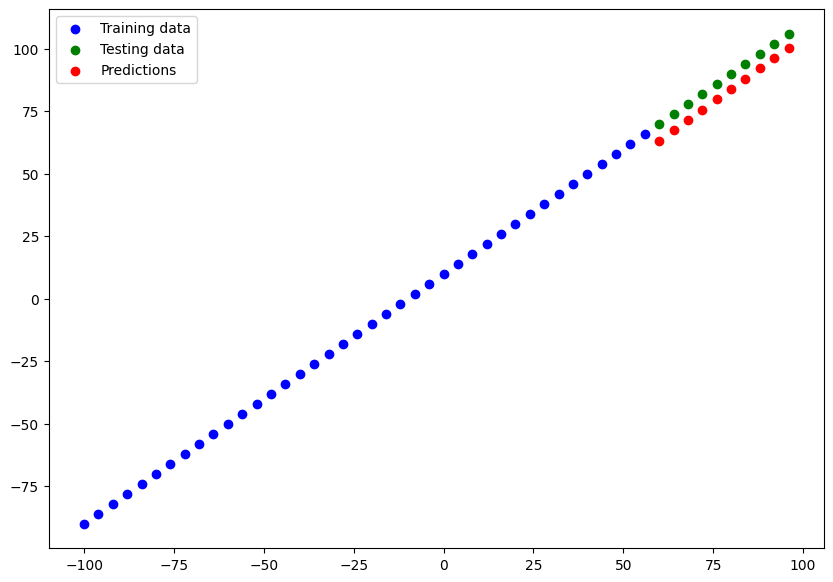

In [ ]:
# make a predict
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [ ]:
# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(6.142785), np.float32(37.862095))

## Xây dựng mô hình 2
Bây giờ ta sẽ thêm 1 layer cho mô hình hiện tại của ta

In [ ]:
tf.random.set_seed(42)

# create a model
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# compile a model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# fit a model
model_2.fit(tf.expand_dims(X_train, -1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 49.6130 - mae: 49.6130 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 25.8543 - mae: 25.8543
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 17.1906 - mae: 17.1906
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 9.8193 - mae: 9.8193
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.7589 - mae: 10.7589
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 11.7523 - mae: 11.7523
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 12.8051 - mae: 12.8051
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 14.5658 - mae: 14.5658
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.6302 - mae: 11.6302
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 12.6833 - mae: 12.6833
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 14.4369 - mae: 14.4369
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 11.5270 - mae: 11.5270
Epoch 13/100
2/2 ━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


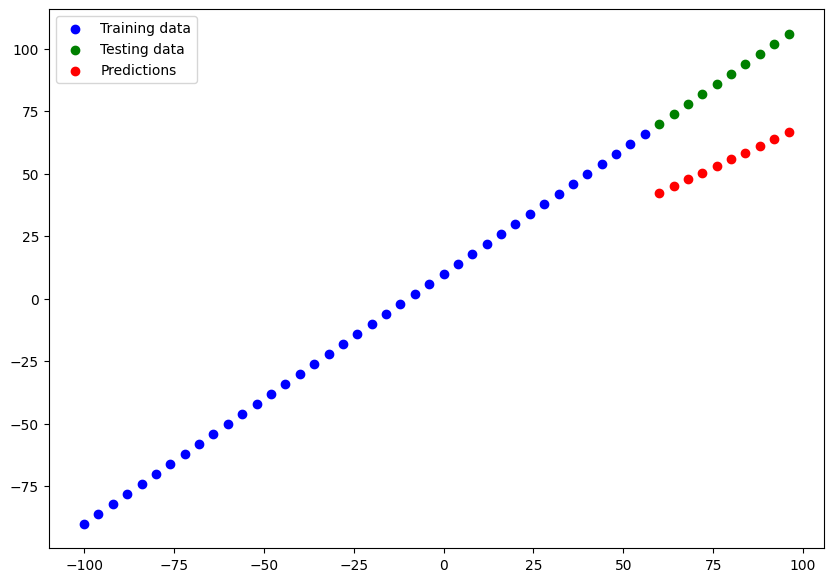

In [ ]:
# make a predict for model 2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [ ]:
# Calculate model_1 metrics
mae_2 = mae(y_test, y_preds_2.squeeze()).numpy()
mse_2 = mse(y_test, y_preds_2.squeeze()).numpy()
mae_2, mse_2

(np.float32(33.542706), np.float32(1139.2402))

## Xây dựng mô hình 3
Mô hình này sẽ giống với mô hình 2, nhưng ta sẽ thay đổi epochs của nó từ 100 lên 500

In [ ]:
tf.random.set_seed(42)

# create a model
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# compile a model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# fit a model
model_3.fit(tf.expand_dims(X_train, -1), y_train, epochs=500, verbose=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


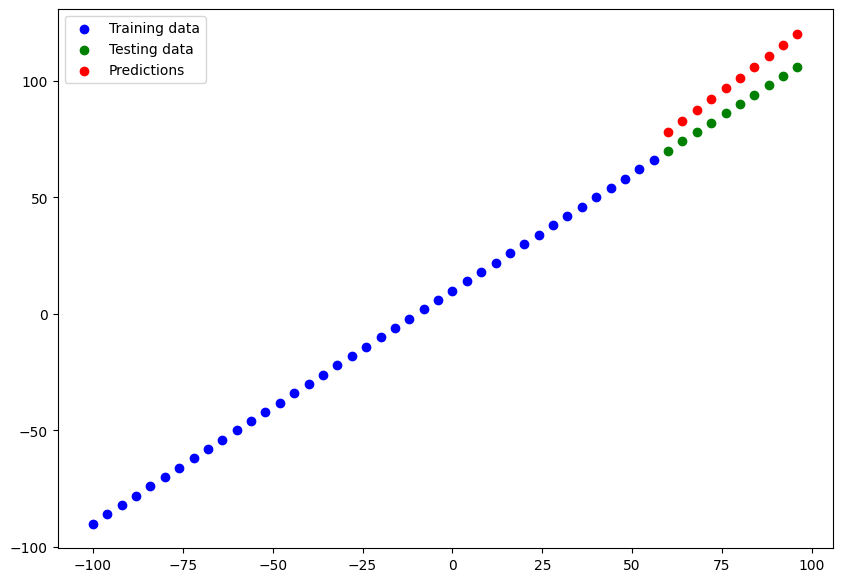

In [ ]:
# make a predict
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [ ]:
# Calculate model_3 metrics
mae_3 = mae(y_test, y_preds_3.squeeze()).numpy()
mse_3 = mse(y_test, y_preds_3.squeeze()).numpy()
mae_3, mse_3

(np.float32(10.997556), np.float32(124.906166))

Qua 3 mô hình mà ta vừa train, ta có thể thấy được không phải cứ thêm layer hay thêm epochs thì mô hình sẽ luôn tốt lên.
## So sánh kết quả
Bây giờ ta đã có kết quả cho 3 mô hình, hãy so sánh chúng.

In [ ]:
model_results = [["model_1", mae_1, mse_1],
                 ["model_2", mae_2, mse_2],
                 ["model_3", mae_3, mae_3]]

In [ ]:
import pandas as pd

all_result = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_result

,model,mae,mse
0,model_1,6.142785,37.862095
1,model_2,33.542706,1139.240234
2,model_3,10.997556,10.997556


# Theo dõi các thí nghiệm
Một thói quen thực sự tốt và cần hình thành là theo dõi các thí nghiệm mô hình của mình để xem thí nghiệm nào hoạt động tốt hơn những thí nghiệm khác.

> 📖 Tài nguyên: Khi ta xây dựng nhiều mô hình hơn, ta sẽ muốn xem xét sử dụng các tool sau:
> 1. [**TensorBoard**](https://tensorboard.dev/) - một thành phần của thư viện TensorFlow giúp theo dõi các thử nghiệm mô hình hóa.
> 2. [**Weights & Biases**](https://wandb.ai/site) - một công cụ theo dõi mọi loại thử nghiệm machine learning (*tin tốt là Weights & Biases có thể kết nối với TensorBoard ở trên*).


# Lưu mô hình
Sau khi đã đào tạo một mô hình và tìm được mô hình hoạt động tốt nhất, ta có thể sẽ muốn lưu mô hình đó để sử dụng ở nơi khác.

Ta có thể lưu mô hình TensorFlow/Keras bằng cách sử dụng hàm `model.save()`.

Có 2 cách để lưu mô hình trong TensorFlow:
1. [Định dạng SavedModel](https://www.tensorflow.org/tutorials/keras/save_and_load#savedmodel_format) (*mặc định*)
2. [Định dạng HDF5](https://www.tensorflow.org/tutorials/keras/save_and_load#hdf5_format)

Sự khác biệt chính giữa hai định dạng này là `SavedModel` có khả năng tự động lưu các đối tượng tùy chỉnh (*chẳng hạn như các layer đặc biệt*) mà không cần sửa đổi thêm khi tải lại mô hình.

Cả hai định dạng đều sử dụng cùng một lệnh gọi hàm:

In [ ]:
model_1.save("save_the_bestest_model.keras")

In [ ]:
!ls save_the_bestest_model.keras

save_the_bestest_model.keras


Bây giờ ta hãy lưu mô hình ở định dạng HDF5

In [ ]:
model_1.save("save_the_bestest_model.h5")

# Tải mô hình
Ta có thể tải 1 mô hình đã lưu bằng hàm `load_model()`

Việc tải mô hình cho các định dạng khác nhau là giống nhau (*miễn là tên đường dẫn đến các định dạng cụ thể là chính xác*).

In [ ]:
loaded_saved_model = tf.keras.models.load_model("save_the_bestest_model.keras")
loaded_saved_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Hãy thử lấy mô hình mà ta vừa tải để so sánh với mô hình trước đó xem coi chúng có khớp với nhau hay không

In [ ]:
model_1_preds = model_1.predict(X_test)
saved_model_preds = loaded_saved_model.predict(X_test)
mae(y_test, saved_model_preds.squeeze()).numpy() == mae(y_test, model_1_preds.squeeze()).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


np.True_

Ok, việc tương tự cũng sẽ diễn ra đối với mô hình `hdf5`

In [ ]:
loaded_saved_hdf5_model = tf.keras.models.load_model("save_the_bestest_model.h5")
loaded_saved_hdf5_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

# Download mô hình (*từ Google Colab*)
Giả sử ta muốn lấy mô hình của mình từ Google Colab về máy cục bộ, ta có thể thực hiện một trong những điều sau:
- Nhấp chuột phải vào tệp trong ngăn tệp và nhấp vào 'Download'.
- Sử dụng code bên dưới

In [ ]:
from google.colab import files
files.download("save_the_bestest_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Một ví dụ lớn hơn
OK bây giờ ta đã biết được cách xây dựng 1 mô hình hồi quy. Hãy thử xây dựng 1 mô hình cho 1 dataset có nhiều dữ liệu cũng như nhiều features hơn.

Cụ thể hơn, ta sẽ thử dự đoán `chi phí bảo hiểm y tế` cho cá nhân dựa trên một số thông số khác nhau như `tuổi`, `giới tính`, `chỉ số BMI`, `trẻ em hay không`, `tình trạng hút thuốc` và `khu vực cư trú`.

> Để thực hiện điều này, ta sẽ tận dụng [bộ dữ liệu Chi phí y tế](https://www.kaggle.com/datasets/mirichoi0218/insurance) có sẵn công khai trên Kaggle hoặc [trên github](https://github.com/stedy/Machine-Learning-with-R-datasets/blob/master/insurance.csv).

In [ ]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [ ]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Ta sẽ phải chuyển các cột *không phải* là number thành number (*vì mạng nơ-ron chỉ xử lý các input là number*).

Để làm được việc đó, ta có thể sử dụng hàm [`get_dummies()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) của pandas

- Nó chuyển đổi các biến phân loại (*như cột `sex`, `smoker` và `region`*) thành các biến số bằng cách sử dụng mã hóa one-hot.

In [ ]:
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


OK bây giờ ta sẽ cần chia dataset hiện tại ra 2 tệp là `X` và `y`. Với `y` sẽ là `changes`

In [ ]:
X = insurance_one_hot.drop("charges", axis=1) # axis: 1 = column -- 0 = row
y = insurance_one_hot["charges"]

In [ ]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


Sau khi đã có feature và label để đưa vào mô hình, việc tiếp theo ta sẽ là chia ra Train set và Test set để thực hiện xây dựng mô hình và đánh già mô hình.

Tại đây ta có thể sử dụng hàm `train_test_split()` của `sklearn`

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
len(X_train), len(y_train), len(X_test), len(y_test)

(1070, 1070, 268, 268)

In [ ]:
X_train.shape, y_train.shape

((1070, 11), (1070,))

Bây giờ ta sẽ tiến hành xây dựng 1 mô hình

In [ ]:
tf.random.set_seed(42)

# create a model
insurance_model = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# compile a model
insurance_model.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# fit a model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10975.1211 - mae: 10975.1211   
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7693.5151 - mae: 7693.5151 
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7591.1826 - mae: 7591.1826
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7870.0713 - mae: 7870.0713 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7389.1875 - mae: 7389.1875 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7305.0933 - mae: 7305.0933 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7841.3604 - mae: 7841.3604 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7499.8984 - mae: 7499.8984 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7266.2031 - mae: 7266.2031 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7461.1748 - mae: 7461.1748 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7191.3491 - mae: 7191.3491 
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━

In [ ]:
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7923.6870 - mae: 7923.6870  


[7881.64453125, 7881.64453125]

Mô hình hiện tại của ta không hoạt động tốt lắm, hãy thử một mô hình lớn hơn.

Ta có thể thử 3 thứ sau:
- Tăng số lượng layer
- Tăng hidden unit trong mỗi layer
- Chuyển đổi optimizer

In [ ]:
tf.random.set_seed(42)

# create a model
insurance_model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

# compile a model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(), # change SGD to Adam
                          metrics=["mae"])

# fit a model
insurance_model_2.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13286.0801 - mae: 13286.0801
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13202.4365 - mae: 13202.4365
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13019.4834 - mae: 13019.4834
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12619.6338 - mae: 12619.6338
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11847.6357 - mae: 11847.6357
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10600.7168 - mae: 10600.7168
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9109.4141 - mae: 9109.4141
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7877.8188 - mae: 7877.8188
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7435.5464 - mae: 7435.5464
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7383.9038 - mae: 7383.9038
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7363.1587 - mae: 7363.1587
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5331.9917 - mae: 5331.9917  


[5163.53369140625, 5163.53369140625]

Đã có sự cải thiện một chút.

Ta đã sử dụng mô hình lớn hơn và thay đổi optimizer Adam cho kết quả lỗi chỉ gần bằng một nửa so với mô hình trước đó.

> 🔑 **Lưu ý**: Đối với nhiều bài toán, [`optimizer Adam`](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) là một lựa chọn khởi đầu tốt. Xem thêm [quan điểm "Adam is safe" của Andrei Karpathy](https://karpathy.github.io/2019/04/25/recipe/) trong cuốn "Công thức huấn luyện mạng nơ-ron".

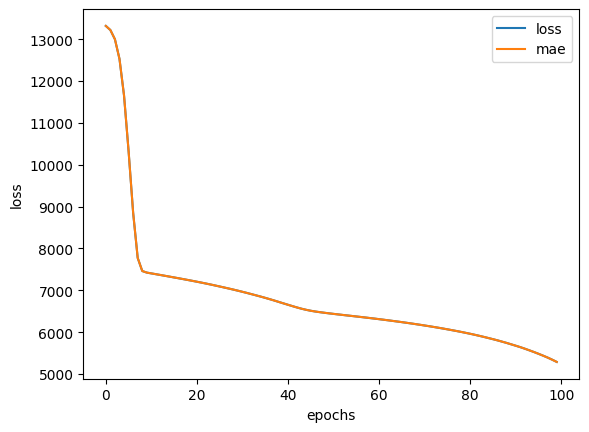

In [ ]:
pd.DataFrame(insurance_model_2.history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs");

Từ biểu đồ trên ta có thể nhận thấy được loss và MAE của mô hình đã giảm xuống khá nhiều trong quá trình training mô hình.

Điều này cho ta biết rằng `loss` có thể giảm xuống nếu ta cố gắng đào tạo nó trong thời gian dài hơn

> Tùy thuộc vào vấn đề ta đang xử lý. Đôi khi việc huấn luyện sẽ không mất nhiều thời gian, nhưng đôi khi lại mất nhiều thời gian hơn dự kiến.
>
> Một phương pháp phổ biến là thiết lập thời gian huấn luyện mô hình của bạn trong một khoảng thời gian rất dài (*ví dụ: hàng nghìn epoch*) nhưng thiết lập nó với [`EarlyStopping callback`](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) để nó tự động dừng khi không còn cải thiện. Chúng ta sẽ tìm hiểu điều này trong một mô-đun khác.

In [ ]:
# Try training for a little longer (100 more epochs)
history_2 = insurance_model_2.fit(X_train, y_train, epochs=100, verbose=0)

In [ ]:
# Evaluate the model trained for 200 total epochs
insurance_model_2_loss, insurance_model_2_mae = insurance_model_2.evaluate(X_test, y_test)
insurance_model_2_loss, insurance_model_2_mae

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3504.5132 - mae: 3504.5132 


(3437.052734375, 3437.052734375)

Ta có thể thấy rằng, khi tăng thời gian huấn luyện (*thêm 100 epoch*) thì loss và mae cũng đã có giảm thiếu khá đáng kể.

Hãy thử đưa chúng lên biểu đồ để xem coi nó đang trống như thế nào

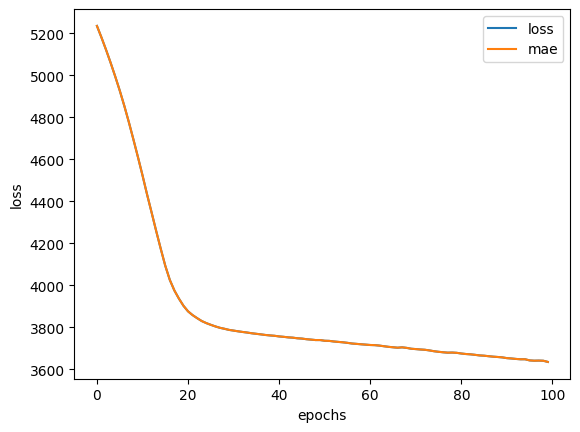

In [ ]:
pd.DataFrame(history_2.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs");

# Tiền xử lý dữ liệu (*normalization và standardization*)
Một thực hành phổ biến khi làm việc với mạng nơ-ron là đảm bảo mọi dữ liệu ta truyền cho chúng đều nằm trong phạm vi từ 0 đến 1.

Điều này được gọi là **normalization** hay là **chuẩn hóa** (*điều chỉnh tất cả các giá trị từ phạm vi ban đầu của chúng thành từ 0 đến 1, ví dụ, từ 0 đến 100.000, thành từ 0 đến 1*).

Có một quy trình khác gọi là **standardization** cũng là chuẩn hóa, chuyển đổi toàn bộ dữ liệu của ta thành phương sai đơn vị (*unit variance*) và giá trị trung bình bằng 0.

Biết được điều này, một số bước chính ta sẽ thực hiện để tiền xử lý dữ liệu cho mạng nơ-ron bao gồm:
- Chuyển toàn bộ dữ liệu thành số
- Đảm bảo dữ liệu có `shape` phù hợp (*xác định input shape và output shape*)
- [**Các tính năng mở rộng**](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-scaler)
  - Normalization dữ liệu (*đảm bảo tất cả các giá trị nằm trong khoảng từ 0 đến 1*). Việc này được thực hiện bằng cách trừ giá trị nhỏ nhất rồi chia cho giá trị lớn nhất trừ đi giá trị nhỏ nhất. Phương pháp này còn được gọi là tỷ lệ min-max (*min-max scaling*).
  - Standardization (*đảm bảo tất cả các giá trị có giá trị trung bình bằng 0 và phương sai bằng 1*). Điều này được thực hiện bằng cách trừ giá trị trung bình từ `target feature`, sau đó chia cho độ lệch chuẩn (*standard deviation*).
  - Ta nên sử dụng cái nào ?
    - Với mạng nơ-ron, ta sẽ có xu hướng ưu tiên **normalization** vì chúng có xu hướng ưu tiên các giá trị từ 0 đến 1 (*ta sẽ thấy điều này đặc biệt khi xử lý hình ảnh*), tuy nhiên, ta thường thấy mạng nơ-ron có thể hoạt động khá tốt với khả năng mở rộng tính năng tối thiểu.

> 📖 **Tài nguyên**: Để biết thêm về cách tiền xử lý dữ liệu, ta nên đọc các tài nguyên sau:
>
> - [Tài liệu của `Scikit-Learn` về tiền xử lý dữ liệu](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing-data)
> - [Mở rộng, normalization hoặc standardization với Scikit-Learn của Jeff Hale.](https://towardsdatascience.com/scikit-learn-vs-sklearn-6944b9dc1736/)

Ta đã chuyển dữ liệu thành số bằng hàm `get_dummies()`, hãy cùng xem cách Ta chuẩn hóa dữ liệu đó như thế nào.

In [ ]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [ ]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Bây giờ, giống như trước, ta cần chuyển đổi các cột phân loại thành số và lần này ta cũng sẽ chuẩn hóa các cột số với các phạm vi khác nhau (*để đảm bảo tất cả chúng đều nằm trong khoảng từ 0 đến 1*).

Để làm được điều này, ta sẽ sử dụng 1 số class từ `sklearn`:
- [`make_column_transformer`](https://scikit-learn.org/stable/modules/generated/sklearn.compose.make_column_transformer.html) - xây dựng một hàm tiền xử lý dữ liệu nhiều bước cho các phép biến đổi sau:
  - [`MinMaxScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) - đảm bảo tất cả các cột số đều được chuẩn hóa (*giữa 0 và 1*)
  - [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) - mã hóa một lần các cột không phải số

Ta hãy xem coi chúng được thực hiện như thế nào:

In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Create a column transformer
ct = make_column_transformer(
  (MinMaxScaler(), ['age', 'bmi', 'children']),
  (OneHotEncoder(handle_unknown="ignore"), ['sex', 'smoker', 'region'])
)

# Create X, y
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

# Build our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit column tranformer to dataset
ct.fit(X_train)

# Transform training and test datasets
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [ ]:
X_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [ ]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

> **Có 1 điều lưu ý** đó là ta sẽ thực hiện fit column tranformer với dữ liệu train mà thôi, còn nếu thực hiện trên dữ liệu Test sẽ dẫn đến việc rò rỉ dữ liệu, việc này khiến đánh giá cuối cùng của ta không còn chính xác nữa.

OK, bây giờ ta hãy cũng xem shape cũng chúng đang trông như thế nào

In [ ]:
X_train_normal.shape, X_train.shape

((1070, 11), (1070, 6))

Hiện giờ data của ta đã được tiền xử lý rất tốt, giờ là lúc để xây dựng mô hình

In [ ]:
tf.random.set_seed(42)

# create a model
insurance_model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

# compile a model
insurance_model_3.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# fit a model
insurance_model_3.fit(X_train_normal, y_train, epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 13297.8506 - mae: 13297.8506
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13290.8906 - mae: 13290.8906
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13273.7568 - mae: 13273.7568
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13236.0225 - mae: 13236.0225
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13166.2188 - mae: 13166.2188
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13052.2383 - mae: 13052.2383
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12883.2451 - mae: 12883.2451
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12649.2744 - mae: 12649.2744
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12340.6201 - mae: 12340.6201
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11949.9941 - mae: 11949.9941
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11484.4736 - mae: 11484.4736
Epoch 12/200
34/34 ━━━━━━━━━━━

In [ ]:
insurance_model_3_loss, insurance_model_3_mae = insurance_model_3.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3213.4863 - mae: 3213.4863 


Và cuối cùng, hãy so sánh kết quả từ `insurance_model_2` (*được đào tạo trên dữ liệu không chuẩn hóa*) và `insurance_model_3` (*được đào tạo trên dữ liệu chuẩn hóa*).

In [ ]:
insurance_model_2_mae, insurance_model_3_mae

(3437.052734375, 3161.02685546875)

Từ đó, ta có thể thấy việc chuẩn hóa dữ liệu mang lại kết quả lỗi ít hơn khoảng 10% khi sử dụng cùng một mô hình so với việc không chuẩn hóa dữ liệu.

> Đây là một trong những lợi ích chính của việc chuẩn hóa dữ liệu: thời gian hội tụ nhanh hơn (*một cách nói hoa mỹ là mô hình của ra sẽ đạt được kết quả tốt hơn nhanh hơn*).
>
> - Nghĩa là `insurance_model_2` sẽ đạt được kết quả giống với `insurance_model_3` nếu nó được train lâu hơn

# Bài tập thực hành
1. Tạo tập dữ liệu hồi quy của riêng bạn (*hoặc làm cho tập dữ liệu ta đã tạo trong phần "Tạo dữ liệu để xem và điều chỉnh" lớn hơn*) và xây dựng một mô hình phù hợp với nó.
2. Hãy thử xây dựng một mạng nơ-ron với 4 lớp Dense và điều chỉnh nó cho tập dữ liệu hồi quy của riêng ta, và xem kết quả như thế nào?
3. Hãy thử và cải thiện kết quả ta đã có trên tập dữ liệu bảo hiểm, một số điều ta có thể muốn thử bao gồm:
  - Xây dựng một mô hình lớn hơn (*mô hình có 4 layer Dense thì sao?*).
  - Tăng số lượng hidden unit trong mỗi layer.
  - Tra cứu tài liệu của Adam và tìm hiểu tham số đầu tiên là gì, điều gì sẽ xảy ra nếu ta tăng nó lên 10 lần?
  - Điều gì sẽ xảy ra nếu ta huấn luyện lâu hơn (*ví dụ 300 epoch thay vì 200*)?
4. Import dataset [giá nhà ở Boston](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/boston_housing/load_data) từ TensorFlow [`tf.keras.datasets`](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) và mô hình hóa nó.

# Đọc thêm
Đọc [Chương 1 của cuốn Mạng nơ-ron và Học sâu](http://neuralnetworksanddeeplearning.com/chap1.html) của Michael Nielson - một ví dụ thực tế và sâu sắc về trực giác đằng sau mạng nơ-ron

Ta cũng có thể đi tới [`Kaggle`](https://www.kaggle.com/datasets) để tìm cho mình 1 dataset hồi quy và thực hành trên nó.